# TCCT S88 - Eight-Branch Frozen-Decoder Blind Test

S87D was frozen and hash-locked before this notebook was built. S88 evaluates the unchanged 27-dimensional QueriedGlobalMoments extractor and frozen decision tree on an unseen eight-branch grammar, depths 61 and 109, two new private-diamond topology compositions, and eight unseen mixed-intervention pairs.

This notebook performs no training, model selection, decoder editing, or retuning. Run once from a fresh kernel and retain either success or failure. Expected workload: 512 worlds; execution may take several minutes.


Dataset[{<|Stage -> S86, Name -> ExternalSixBranchBlind, CandidateFileLoaded -> True, 
 
>     CandidateHash -> a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     ExpectedCandidateHash -> 
 
>      a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f, 
 
>     CandidateK -> 19, CandidatePolicyLength -> 26, 
 
>     OriginalFrozenModelChanged -> False, FrozenCandidateChanged -> False, 
 
>     CoreChanged -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Stage, Name, CandidateFileLoaded, 
 
>      CandidateHash, ExpectedCandidateHash, CandidateK, CandidatePolicyLength, 
 
>      OriginalFrozenModelChanged, FrozenCandidateChanged, CoreChanged, PreflightPassed}\
 
>      , {TypeSystem`Atom[String], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[String], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
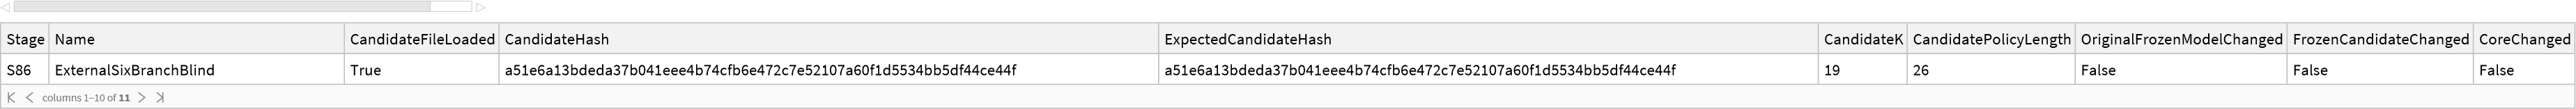

In [5]:
ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8661d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];

ClearAll[ChainIn63, SharedMerge63, Case63];
ChainIn63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, inc, rm, add, new, n},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
inc=Cases[
e,
DirectedEdge[u_, v_ ] /; MemberQ[f, v]:>{u, v}
];
rm=DirectedEdge@@@inc;
add=Flatten[
Table[
n=mx+i;
{
DirectedEdge[inc[[i, 1]], n],
DirectedEdge[n, inc[[i, 2]]]
},
{i, Length[inc]}
],
1
];
new=Union[
Join[
Complement[e, rm],
add
]
];
{{new, x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
SharedMerge63[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, ps, rm, g, i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>u
];
rm=(DirectedEdge[#, m]&)/@ps;
new=Complement[
new,
rm
];
g=mx+i;
new=Join[
new,
(DirectedEdge[#, g]&)/@ps,
{DirectedEdge[g, m]}
],
{i, Length[f]}
];
{{Union[new], x[[2]], x[[3]], x[[4]], x[[5]], x[[6]]}, a}
];
Case63[
g_String ,
d_Integer,
a_Integer,
t_String
]:=
Switch[
g,
"ChainIn",
ChainIn63[Case59[d, a, t]],
"SharedMerge",
SharedMerge63[Case59[d, a, t]]
];

ClearAll[ParallelIn71];
ParallelIn71[c_List]:=Module[
{x=c[[1]], a=c[[2]], e, f, mx, new, m, incs, rm,
add, next, g1, g2, i, j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_, v_ ] /; v===m:>{u, v}
];
rm=DirectedEdge@@@incs;
add= {};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[incs[[j, 1]], g1],
DirectedEdge[g1, m],
DirectedEdge[incs[[j, 1]], g2],
DirectedEdge[g2, m]
}
],
{j, Length[incs]}
];
new=Join[
Complement[new, rm],
add
],
{i, Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
}, a}
];

(* In[410] *)
ClearAll[Case71];
Case71[
d_Integer,
a_Integer,
t_String
]:=
ParallelIn71[
Case59[d, a, t]
];

ClearAll[ParallelOut72,SharedParallelIn72,Case72B];
ParallelOut72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,outs,rm,
add,g1,g2,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
outs=Cases[
new,
DirectedEdge[u_,v_]/;u===m:>{u,v}
];
rm=DirectedEdge@@@outs;
add={};
Do[
g1=next;
g2=next+1;
next=next+2;
add=Join[
add,
{
DirectedEdge[m,g1],
DirectedEdge[g1,outs[[j,2]]],
DirectedEdge[m,g2],
DirectedEdge[g2,outs[[j,2]]]
}
],
{j,Length[outs]}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

SharedParallelIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,ps,rm,
g1,g2,add,i},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
ps=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>u
];
rm=(DirectedEdge[#,m]&)/@ps;
g1=next;
g2=next+1;
next=next+2;
add=Join[
Flatten[
Table[
{
DirectedEdge[ps[[j]],g1],
DirectedEdge[ps[[j]],g2]
},
{j,Length[ps]}
],
1
],
{
DirectedEdge[g1,m],
DirectedEdge[g2,m]
}
];
new=Join[
Complement[new,rm],
add
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]
},a}
];

Case72B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"ParallelOut",
ParallelOut72[Case59[depth,answer,target]],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"SharedParallelIn",
SharedParallelIn72[Case59[depth,answer,target]],
_,
$Failed
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelDefinitionTextHash86=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash86=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedStableFrozenArchitectureHash86=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedInterventionHash86=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedCandidateHash86=
"a51e6a13bdeda37b041eee4b74cfb6e472c7e52107a60f1d5534bb5df44ce44f";

candidateSnapshotPath86=
"E:/engine_wolf/TCCT_S83B_FrozenCandidate.wl";

If[
!FileExistsQ[candidateSnapshotPath86],
Print["S86 aborted: frozen S83B candidate file is missing."];
Abort[]
];

Get[candidateSnapshotPath86];

ClearAll[CoreDefinitionBundle86];
CoreDefinitionBundle86[]:={
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
};

minimalKernelDefinitionTextHash86=Hash[
ToString[InputForm[CoreDefinitionBundle86[]]],
"SHA256","HexString"
];

stableFrozenArchitectureHash86=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash86,
canonicalizerImplementationHash79B
},
"SHA256","HexString"
];

candidateHashLoaded86=If[
AssociationQ[frozenCandidate83B],
Hash[Normal[frozenCandidate83B],"SHA256","HexString"],
Missing["CandidateNotLoaded"]
];

preflightPassed86=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash86,
expectedMinimalKernelDefinitionTextHash86
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash86
],
SameQ[
stableFrozenArchitectureHash86,
expectedStableFrozenArchitectureHash86
],
SameQ[interventionImplementationHash82,expectedInterventionHash86],
AssociationQ[frozenCandidate83B],
SameQ[candidateHashLoaded86,expectedCandidateHash86],
SameQ[frozenCandidate83B["BaseFrozenModelHash"],expectedFrozenModelHash79A],
SameQ[frozenCandidate83B["EncoderParams"],frozen75D["Params"]],
SameQ[frozenCandidate83B["Representation"],"KExactRole"],
SameQ[frozenCandidate83B["K"],19],
SameQ[Length[frozenCandidate83B["Policy"]],26],
SameQ[frozenCandidate83B["DevelopmentScore"],264],
TrueQ[frozenCandidate83B["ExactNodeRoleUsed"]],
TrueQ[frozenCandidate83B["FrozenBeforeS84"]]
];

preflight86=<|
"Stage"->"S86",
"Name"->"ExternalSixBranchBlind",
"CandidateFileLoaded"->FileExistsQ[candidateSnapshotPath86],
"CandidateHash"->candidateHashLoaded86,
"ExpectedCandidateHash"->expectedCandidateHash86,
"CandidateK"->If[AssociationQ[frozenCandidate83B],frozenCandidate83B["K"],Missing[]],
"CandidatePolicyLength"->If[
AssociationQ[frozenCandidate83B],Length[frozenCandidate83B["Policy"]],Missing[]
],
"OriginalFrozenModelChanged"->False,
"FrozenCandidateChanged"->False,
"CoreChanged"->False,
"PreflightPassed"->preflightPassed86
|>;

If[
!TrueQ[preflightPassed86],
Print[Dataset[{preflight86}]];
Print["S86 aborted: frozen architecture or S83B candidate mismatch."];
Abort[]
];

Dataset[{preflight86}]


Dataset[{<|Stage -> S88, Name -> EightBranchFrozenDecoderBlind, 
 
>     CandidateFrozenBeforeProtocol -> True, 
 
>     DecoderCandidateHash -> 
 
>      703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     DecoderCandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, BranchCount -> 8, 
 
>     Depths -> {61, 109}, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DecoderEditApplied -> False, RetuningApplied -> False, 
 
>     S88ResultAlreadyPresent -> False, PreflightPassed -> True|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 17], 
 
>    1], <||>]
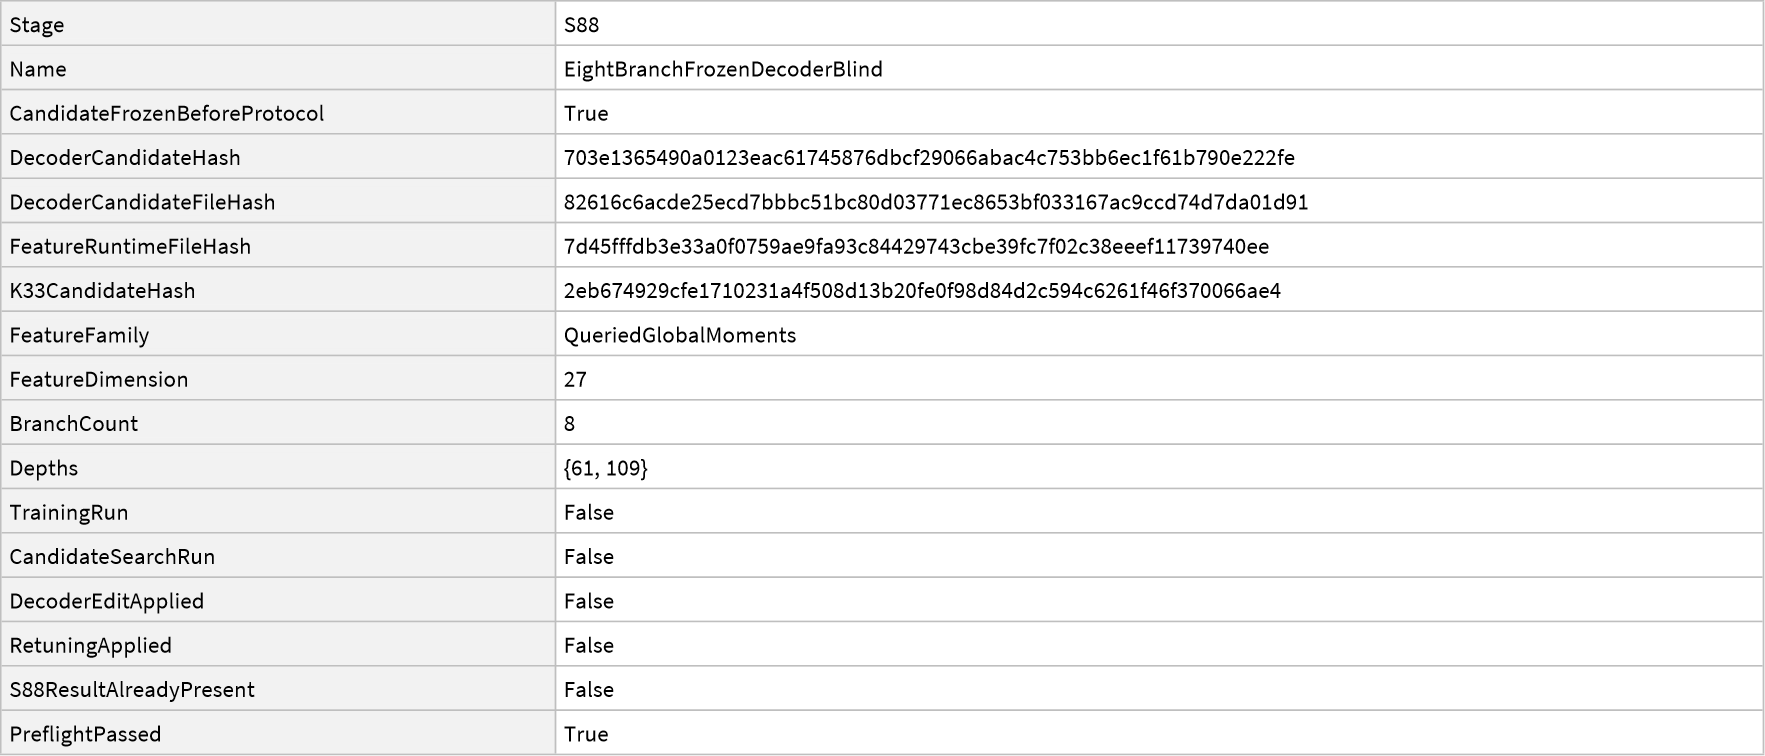

In [89]:
expectedFrozenModelHash88=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedK33CandidateHash88=
"2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4";
expectedK33CandidateFileHash88=
"4a252b8977101d024b1b2feb00b4626ca28290c3982cdad199bc78ef7e0c98f1";
expectedDecoderCandidateHash88=
"703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe";
expectedDecoderCandidateFileHash88=
"82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91";
expectedClassifierBinaryHash88=
"2b8861c03c8169571061a85c12644c6e30a11e8f8f15f5c69c6761215f4752f1";
expectedFeatureRuntimeFileHash88=
"7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee";
expectedFreezeProtocolHash88=
"03d7a40eefdaec9d9fce599517d3663ba381d50218bfe4934580bd22ca31b86c";
expectedFreezeCertificateFileHash88=
"7c83717fc5bf50b1bde853401da8d0fc5931d6b1b23663d75777e1e45516fb8e";

k33CandidatePath88="E:/engine_wolf/TCCT_S86E_K33FrozenCandidate.wl";
decoderRuntimePath88="E:/engine_wolf/TCCT_S87D_FrozenDecoderRuntime.wl";
decoderCandidatePath88=
"E:/engine_wolf/TCCT_S87D_FrozenWorldMultisetDecoder.wxf";
freezeCertificatePath88="E:/engine_wolf/TCCT_S87D_FreezeCertificate.json";
s88ResultCertificatePath=
"E:/engine_wolf/TCCT_S88_BlindResultCertificate.json";

ClearAll[FileSHA256Hex88];
FileSHA256Hex88[path_String]:=If[
FileExistsQ[path],
IntegerString[FileHash[path,"SHA256"],16,64],
Missing["FileMissing",path]
];

requiredFilesPresent88=And@@Map[
FileExistsQ,
{
k33CandidatePath88,decoderRuntimePath88,
decoderCandidatePath88,freezeCertificatePath88
}
];

If[
!TrueQ[requiredFilesPresent88],
Print["S88 aborted: one or more frozen input files are missing."];
Abort[]
];

If[
FileExistsQ[s88ResultCertificatePath],
Print["S88 aborted: a prior S88 result certificate already exists."];
Print["Preserve the prior blind result; do not overwrite or retune."];
Abort[]
];

k33CandidateFileHashBefore88=FileSHA256Hex88[k33CandidatePath88];
decoderRuntimeFileHashBefore88=FileSHA256Hex88[decoderRuntimePath88];
decoderCandidateFileHashBefore88=FileSHA256Hex88[decoderCandidatePath88];
freezeCertificateFileHashBefore88=FileSHA256Hex88[freezeCertificatePath88];

Clear[frozenCandidate86E];
Get[k33CandidatePath88];
k33CandidateHashLoaded88=If[
AssociationQ[frozenCandidate86E],
Hash[Normal[frozenCandidate86E],"SHA256","HexString"],
Missing["K33CandidateNotLoaded"]
];

Get[decoderRuntimePath88];
frozenDecoderLoaded88=TCCTLoadFrozenDecoderS87D[decoderCandidatePath88];
frozenDecoderRaw88=If[
AssociationQ[frozenDecoderLoaded88],
KeyDrop[frozenDecoderLoaded88,{"Classifier"}],
$Failed
];
decoderCandidateHashLoaded88=If[
AssociationQ[frozenDecoderRaw88],
Lookup[frozenDecoderRaw88,"CandidateHash",Missing["CandidateHashMissing"]],
Missing["DecoderNotLoaded"]
];
decoderPayloadHashLoaded88=If[
AssociationQ[frozenDecoderRaw88],
Hash[
Normal[KeyDrop[frozenDecoderRaw88,{"CandidateHash"}]],
"SHA256","HexString"
],
Missing["DecoderNotLoaded"]
];

freezeCertificate88=Quiet@Check[
Import[freezeCertificatePath88,"RawJSON"],
$Failed
];

ClearAll[CoreDefinitionBundle88];
CoreDefinitionBundle88[]:=CoreDefinitionBundle86[];

modelHashBefore88=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashBefore88=Hash[
Normal[frozenCandidate86E],"SHA256","HexString"
];
decoderObjectHashBefore88=If[
AssociationQ[frozenDecoderRaw88],
Hash[Normal[frozenDecoderRaw88],"SHA256","HexString"],
Missing["DecoderNotLoaded"]
];
coreHashBefore88=Hash[CoreDefinitionBundle88[],"SHA256","HexString"];
canonicalizerHashBefore88=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashBefore88=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyPrimitiveHashBefore88=Hash[
{
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]
},
"SHA256","HexString"
];
decoderRuntimeDefinitionHashBefore88=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"
];

preflightPassed88=And[
TrueQ[preflightPassed86],
SameQ[modelHashBefore88,expectedFrozenModelHash88],
AssociationQ[frozenCandidate86E],
SameQ[k33CandidateHashLoaded88,expectedK33CandidateHash88],
SameQ[k33CandidateFileHashBefore88,expectedK33CandidateFileHash88],
SameQ[frozenCandidate86E["K"],33],
SameQ[frozenCandidate86E["Representation"],"KExactRole"],
AssociationQ[frozenDecoderLoaded88],
AssociationQ[frozenDecoderRaw88],
Head[frozenDecoderLoaded88["Classifier"]]===ClassifierFunction,
SameQ[decoderCandidateHashLoaded88,expectedDecoderCandidateHash88],
SameQ[decoderPayloadHashLoaded88,expectedDecoderCandidateHash88],
SameQ[decoderCandidateFileHashBefore88,expectedDecoderCandidateFileHash88],
SameQ[decoderRuntimeFileHashBefore88,expectedFeatureRuntimeFileHash88],
SameQ[frozenDecoderRaw88["ClassifierBinaryHash"],
expectedClassifierBinaryHash88],
SameQ[frozenDecoderRaw88["FeatureRuntimeFileHash"],
FileHash[decoderRuntimePath88,"SHA256"]],
SameQ[frozenDecoderRaw88["ProtocolHash"],expectedFreezeProtocolHash88],
SameQ[frozenDecoderRaw88["FeatureFamily"],"QueriedGlobalMoments"],
SameQ[frozenDecoderRaw88["FeatureDimension"],27],
SameQ[Length[frozenDecoderRaw88["FeatureNames"]],27],
SameQ[frozenDecoderRaw88["K"],33],
SameQ[frozenDecoderRaw88["BaseFrozenModelHash"],
expectedFrozenModelHash88],
SameQ[frozenDecoderRaw88["BaseK33CandidateHash"],
expectedK33CandidateHash88],
TrueQ[frozenDecoderRaw88["FrozenBeforeS88"]],
TrueQ[frozenDecoderRaw88["S88DataReadBeforeFreeze"]===False],
AssociationQ[freezeCertificate88],
SameQ[freezeCertificateFileHashBefore88,
expectedFreezeCertificateFileHash88],
TrueQ[freezeCertificate88["FreezeValidityPassed"]],
TrueQ[freezeCertificate88["ReadyForS88"]],
SameQ[freezeCertificate88["CandidateHash"],
expectedDecoderCandidateHash88],
SameQ[freezeCertificate88["Outcome"],
"S87D_DECODER_FROZEN_AND_LOCKED_READY_FOR_S88"],
TrueQ[freezeCertificate88["CoreChanged"]===False],
TrueQ[freezeCertificate88["S88DataReadBeforeFreeze"]===False],
!FileExistsQ[s88ResultCertificatePath]
];

preflight88=<|
"Stage"->"S88",
"Name"->"EightBranchFrozenDecoderBlind",
"CandidateFrozenBeforeProtocol"->True,
"DecoderCandidateHash"->decoderCandidateHashLoaded88,
"DecoderCandidateFileHash"->decoderCandidateFileHashBefore88,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore88,
"K33CandidateHash"->k33CandidateHashLoaded88,
"FeatureFamily"->If[
AssociationQ[frozenDecoderRaw88],
frozenDecoderRaw88["FeatureFamily"],Missing[]
],
"FeatureDimension"->If[
AssociationQ[frozenDecoderRaw88],
frozenDecoderRaw88["FeatureDimension"],Missing[]
],
"BranchCount"->8,
"Depths"->{61,109},
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"S88ResultAlreadyPresent"->FileExistsQ[s88ResultCertificatePath],
"PreflightPassed"->preflightPassed88
|>;

If[
!TrueQ[preflightPassed88],
Print[Dataset[{preflight88}]];
Print["S88 aborted: frozen decoder, architecture, or file lock mismatch."];
Abort[]
];

Dataset[{preflight88}]


Dataset[{<|Stage -> S88, Name -> EightBranchFrozenDecoderBlind, 
 
>     Candidate -> S87D-FrozenWorldMultisetDecoder, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     FeatureRuntimeFileHash -> 
 
>      7d45fffdb3e33a0f0759ae9fa93c84429743cbe39fc7f02c38eeef11739740ee, 
 
>     K33CandidateHash -> 
 
>      2eb674929cfe1710231a4f508d13b20fe0f98d84d2c594c6261f46f370066ae4, 
 
>     BranchCount -> 8, Depths -> {61, 109}, 
 
>     Topologies -> {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     TopologySpecHash -> 
 
>      b0f170713c4594a0b2b51aba5febf1f27e23a26f732149deaf31ec0088ad2b95, 
 
>     InterventionPairs -> 
 
>      {{1, 4}, {2, 5}, {3, 6}, {4, 7}, {5, 8}, {6, 1}, {7, 2}, {8, 3}}, 
 
>     ExpectedScenarios -> 32, ExpectedWorldPairs -> 256, ExpectedWorlds -> 512, 
 
>     ExpectedBaselineWorlds -> 256, ExpectedInterventionContinueWorlds -> 224, 
 
>     ExpectedInterventionStopWorlds -> 32, 
 
>     ExternalGrammar -> IndependentEightBranchT88, 
 
>     Intervention -> OneRedundantPathCutPlusOneBranchStopPatch, 
 
>     QueryGrid -> AllEightQueriesBeforeAndAfterMixedIntervention, 
 
>     FeatureFamily -> QueriedGlobalMoments, FeatureDimension -> 27, 
 
>     ObservationAggregation -> FullQueriedObservationMultisetWithoutCodeDeduplication, 
 
>     LegacyTokenDeduplication -> DeleteDuplicatesAfterExactRoleCodePairing, 
 
>     SuccessCriterion -> ValidHarnessAndAll512WorldsCorrectIncludingBothClasses, 
 
>     CandidateFrozenBeforeProtocol -> True, TrainingRun -> False, 
 
>     CandidateSearchRun -> False, DecoderEditApplied -> False, 
 
>     RetuningApplied -> False, S87LabelsReadByS88 -> False, 
 
>     NoCaseEvaluatedBeforeProtocolHash -> True, 
 
>     ProtocolHash -> 4b4fb0b0c5c5dc91a4f37631b84658edaa81a8a7bd890e5527eebb040b4e19c7, 
 
>     TestDefinitionHash -> 
 
>      548ba783e7a60fdd378c51e34f627e7436038cc3b2cca855333ccde0be75c3ea|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 35], 
 
>    1], <||>]
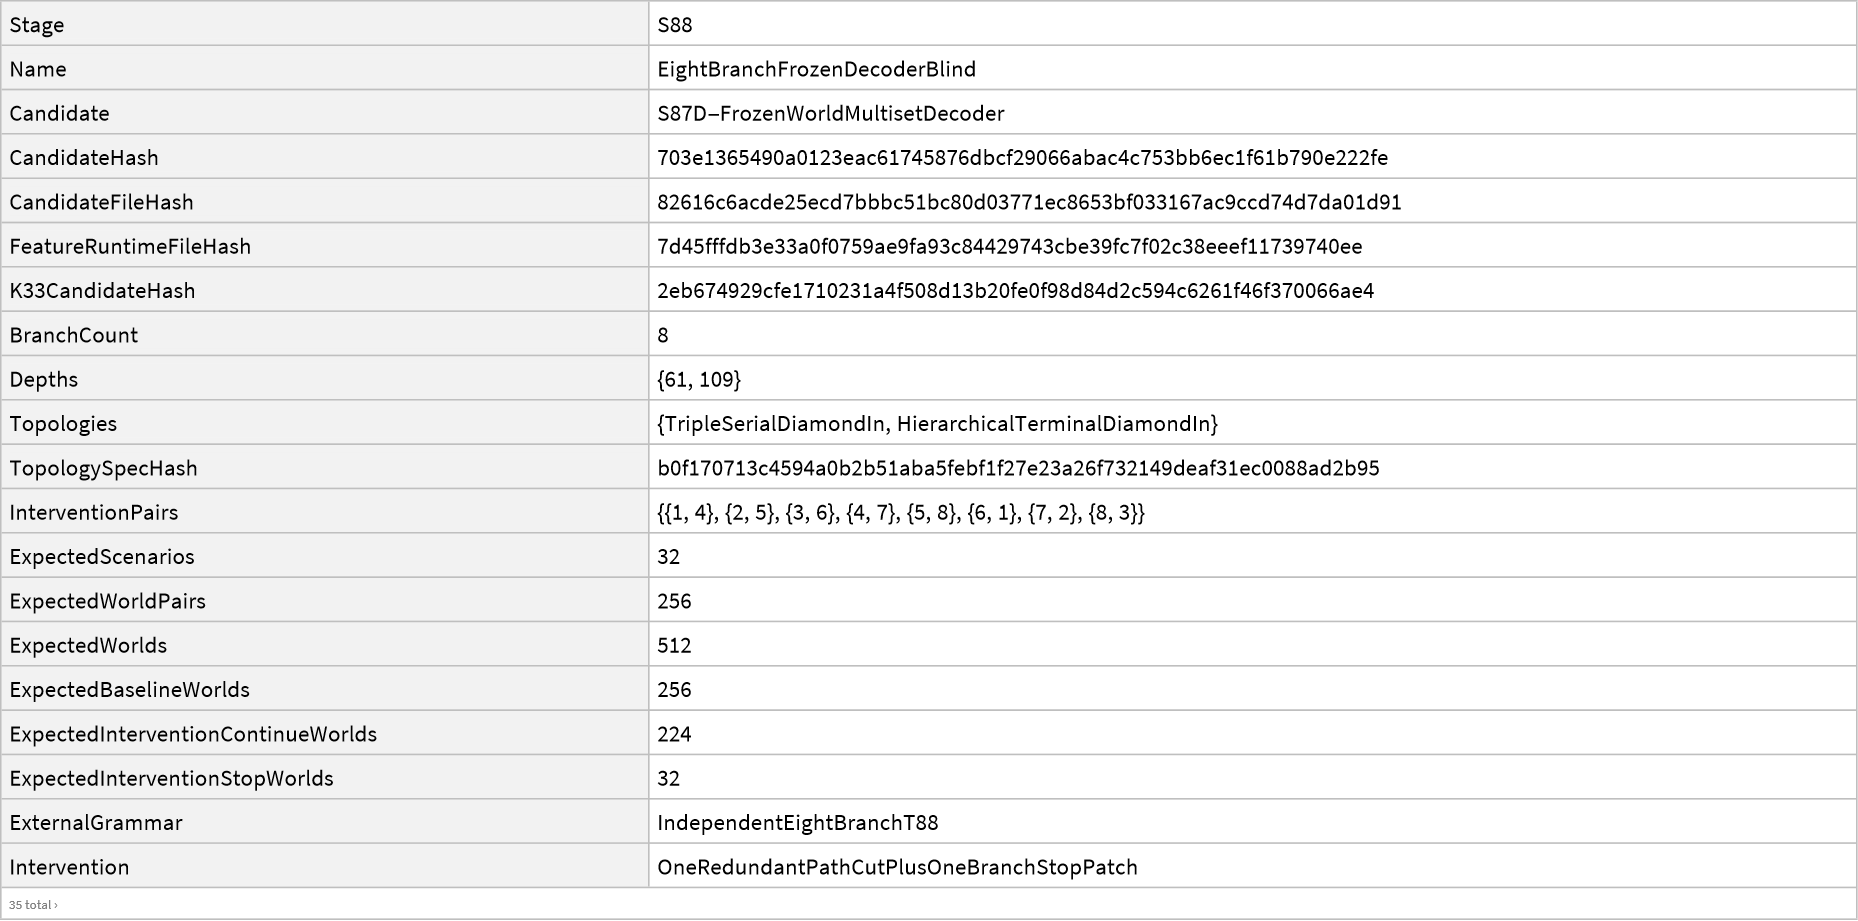

In [135]:
ClearAll[
T88,
Case88,
ReferenceAction88,
NodeRole88,
EncodePair88,
LegacyPredictTokens88,
PredictFrozenDecoder88,
TripleSerialDiamondIn88,
HierarchicalTerminalDiamondIn88,
SetAnswer88,
TopologyTransform88,
ExpectedContractions88,
BranchStopPatch88,
PathCutPatch88,
MixedPathCutStopPatch88,
PrepareWorld88,
PrepareScenario88,
S88TestDefinitionBundle
];


T88[
depth_Integer,
target_String,
answer_Integer,
seed_Integer,
branchCount_Integer
]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dummy,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,branchCount}];
v=Table[bb+200+i,{i,branchCount}];
q=Table[bb+300+i,{i,branchCount}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,branchCount}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dummy=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,branchCount]]];
main=Join[
P59[q[[i]],r1,depth,ib+1000000],
P59[q[[i]],r2,depth,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,depth+1,ib+3000000]
];
perm=If[
target==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dummy]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,branchCount}
];
{{Union[e],q,K,v,c,f},answer}
];

Case88[depth_Integer,answer_Integer,target_String]:=
T88[depth,target,answer,88000000+100 depth,8];

ReferenceAction88[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],branchCount,e,m,safe,u,dummy,
correct,wrong,continueEdges,stopEdges
},
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],"Stop",
True,"Undefined"
]
];

NodeRole88[originalNode_,case_List,answer_Integer]:=Module[
{x,branchCount,m,correct,wrong,dummy,querySources,queryBranch,role},
x=case[[1]];
branchCount=Length[x[[6]]];
m=x[[6,answer]];
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,branchCount]]];
dummy=m+3;
querySources={m,m+1,m+2};
queryBranch=Union[querySources,{correct,wrong,dummy}];
role=Which[
SameQ[originalNode,m],"QueriedDecision",
MemberQ[querySources,originalNode],"QueriedMediatorSource",
SameQ[originalNode,correct],"QueriedCorrectDestination",
SameQ[originalNode,wrong],"QueriedWrongDestination",
SameQ[originalNode,dummy],"QueriedDummyDestination",
MemberQ[x[[6]],originalNode],"OtherDecision",
MemberQ[x[[5]],originalNode],"OtherAnswerDestination",
True,"OtherReject"
];
<|
"Role"->role,
"QueryBranchRelated"->MemberQ[queryBranch,originalNode]
|>
];

EncodePair88[pair_List]:=Module[{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S88BlindObservation",
"Depth"->0,"Answer"->0,"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozenCandidate86E["EncoderParams"],
frozenCandidate86E["K"]
];
First[encoded["Codes"]]
];

LegacyPredictTokens88[tokens_List]:=If[
AnyTrue[tokens,MemberQ[frozenCandidate86E["Policy"],#]&],
"Continue",
"Stop"
];

PredictFrozenDecoder88[observations_List]:=Module[{probe,prediction},
probe=<|"Observations"->observations|>;
prediction=TCCTPredictWorldS87D[probe,frozenDecoderLoaded88];
If[MemberQ[{"Continue","Stop"},prediction],prediction,$Failed]
];

SetAnswer88[c_List,answer_Integer]:={c[[1]],answer};

TripleSerialDiamondIn88[c_List]:=
DiamondIn72[DoubleDiamondIn79[c]];

HierarchicalTerminalDiamondIn88[c_List]:=
DiamondIn72[HierarchicalDiamondIn80[c]];

TopologyTransform88[topology_String,c_List]:=Switch[
topology,
"TripleSerialDiamondIn",TripleSerialDiamondIn88[c],
"HierarchicalTerminalDiamondIn",HierarchicalTerminalDiamondIn88[c],
_,$Failed
];

ExpectedContractions88[topology_String,baseCase_List]:=Switch[
topology,
"TripleSerialDiamondIn",3 DecisionIncomingEdgeCount79B[baseCase],
"HierarchicalTerminalDiamondIn",4 DecisionIncomingEdgeCount79B[baseCase],
_,Missing["UnknownTopology"]
];

BranchStopPatch88[c_List,branch_Integer]:=Module[
{x,branchCount,e,m,safe,u,dummy,correct,wrong,remove,add},
x=c[[1]];
branchCount=Length[x[[6]]];
e=x[[1]];
m=x[[6,branch]];
safe=m+1;
u=m+2;
dummy=m+3;
correct=x[[5,branch]];
wrong=x[[5,1+Mod[branch,branchCount]]];
remove={
DirectedEdge[m,correct],
DirectedEdge[safe,dummy],
DirectedEdge[u,wrong]
};
add={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dummy]
};
<|
"Remove"->remove,
"Add"->add,
"ValidOnInput"->And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
]
|>
];

PathCutPatch88[c_List,branch_Integer]:=Module[
{x,e,m,cutEdge,remainingEdge},
x=c[[1]];
e=x[[1]];
m=x[[6,branch]];
cutEdge=DirectedEdge[m+9,m];
remainingEdge=DirectedEdge[m+19,m];
<|
"Remove"->{cutEdge},
"Add"->{},
"ValidOnInput"->And[
MemberQ[e,cutEdge],MemberQ[e,remainingEdge]
]
|>
];

MixedPathCutStopPatch88[c_List,interventionPair_List]:=Module[
{cutPart,stopPart,remove,add},
cutPart=PathCutPatch88[c,First[interventionPair]];
stopPart=BranchStopPatch88[c,Last[interventionPair]];
remove=DeleteDuplicates@Join[cutPart["Remove"],stopPart["Remove"]];
add=DeleteDuplicates@Join[cutPart["Add"],stopPart["Add"]];
<|
"Remove"->remove,
"Add"->add,
"CutBranch"->First[interventionPair],
"StopBranch"->Last[interventionPair],
"ComponentPatchesValid"->And[
TrueQ[cutPart["ValidOnInput"]],TrueQ[stopPart["ValidOnInput"]]
],
"NoCrossBranchConflict"->Intersection[remove,add]==={},
"ExpectedEditCount"->And[Length[remove]===4,Length[add]===3]
|>
];

PrepareWorld88[
topology_String,
depth_Integer,
interventionPair_List,
graphCondition_String,
answer_Integer,
target_String,
baseCase_List
]:=Module[
{
topologyCase,canonicalization,canonicalCase,expectedContractions,
traceSeconds,trace,levels,pack,vertexList,packedNodes,
observations,originalNode,pair,roleInfo,rawTokens,tokens,featureVector,legacyPrediction,prediction
},
topologyCase=TopologyTransform88[topology,baseCase];
canonicalization=CanonicalizePrivateDiamonds79B[topologyCase];
canonicalCase=canonicalization["Case"];
expectedContractions=ExpectedContractions88[topology,baseCase];
{traceSeconds,trace}=AbsoluteTiming[RejectTrace78[canonicalCase]];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
packedNodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
observations=Map[
Function[packedNode,
originalNode=vertexList[[packedNode]];
pair={Lookup[levels[[3]],packedNode],Lookup[levels[[4]],packedNode]};
roleInfo=NodeRole88[originalNode,canonicalCase,answer];
<|
"Role"->roleInfo["Role"],
"QueryBranchRelated"->roleInfo["QueryBranchRelated"],
"Code"->EncodePair88[pair]
|>
],
packedNodes
];
rawTokens=({#1["Role"],#1["Code"]}&)/@observations;
tokens=DeleteDuplicates[rawTokens];
featureVector=TCCTWorldVectorS87D[<|"Observations"->observations|>];
legacyPrediction=LegacyPredictTokens88[tokens];
prediction=PredictFrozenDecoder88[observations];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"GraphCondition"->graphCondition,
"Answer"->answer,
"Target"->target,
"ReferenceAction"->ReferenceAction88[canonicalCase],
"BranchCount"->Length[canonicalCase[[1,6]]],
"Prediction"->prediction,
"LegacyPrediction"->legacyPrediction,
"FeatureVector"->featureVector,
"Correct"->SameQ[prediction,target],
"TopologyGraphHash"->Hash[topologyCase[[1,1]],"SHA256","HexString"],
"CanonicalGraphHash"->Hash[canonicalCase[[1,1]],"SHA256","HexString"],
"CanonicalCaseExactlyBase"->SameQ[canonicalCase,baseCase],
"Contractions"->canonicalization["Contractions"],
"ExpectedContractions"->expectedContractions,
"ContractionCountCorrect"->SameQ[
canonicalization["Contractions"],expectedContractions
],
"ProtectedNodesPreserved"->canonicalization["ProtectedNodesPreserved"],
"StateObservationCount"->Length[observations],
"RawTokenCount"->Length[rawTokens],
"TokenCount"->Length[tokens],
"DuplicateTokensRemoved"->Length[rawTokens]-Length[tokens],
"LegacyPolicyHitTokens"->Intersection[tokens,frozenCandidate86E["Policy"]],
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"Rounds"->trace["Rounds"],
"TraceSeconds"->traceSeconds
|>
];

PrepareScenario88[
topology_String,depth_Integer,interventionPair_List
]:=Module[
{
branchCount=8,seedCase,patch,hybridSeed,baseWorlds,hybridWorlds,
worldPairs,baseGraphHashes,hybridGraphHashes
},
seedCase=Case88[depth,1,"Continue"];
patch=MixedPathCutStopPatch88[seedCase,interventionPair];
hybridSeed=ApplyEdgePatch81[seedCase,patch];
If[SameQ[hybridSeed,$Failed],Return[$Failed]];
baseWorlds=Table[
PrepareWorld88[
topology,depth,interventionPair,"Baseline",answer,"Continue",
SetAnswer88[seedCase,answer]
],
{answer,Range[branchCount]}
];
hybridWorlds=Table[
PrepareWorld88[
topology,depth,interventionPair,"MixedPathCutStopIntervention",answer,
If[SameQ[answer,Last[interventionPair]],"Stop","Continue"],
SetAnswer88[hybridSeed,answer]
],
{answer,Range[branchCount]}
];
worldPairs=MapThread[
Function[{base,hybrid},
<|
"Answer"->base["Answer"],
"StopPatchedQuery"->SameQ[Last[interventionPair],base["Answer"]],
"SameQuery"->SameQ[base["Answer"],hybrid["Answer"]],
"ReferenceRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Stop"]
],
And[
SameQ[base["ReferenceAction"],"Continue"],
SameQ[hybrid["ReferenceAction"],"Continue"]
]
],
"PredictionRelationCorrect"->If[
SameQ[Last[interventionPair],base["Answer"]],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Stop"]
],
And[
SameQ[base["Prediction"],"Continue"],
SameQ[hybrid["Prediction"],"Continue"]
]
],
"PairCorrect"->And[TrueQ[base["Correct"]],TrueQ[hybrid["Correct"]]],
"BaselineWorld"->base,
"InterventionWorld"->hybrid
|>
],
{baseWorlds,hybridWorlds}
];
baseGraphHashes=Lookup[baseWorlds,"TopologyGraphHash"];
hybridGraphHashes=Lookup[hybridWorlds,"TopologyGraphHash"];
<|
"Topology"->topology,
"Depth"->depth,
"InterventionPair"->interventionPair,
"MixedInterventionValidity"->patch["ComponentPatchesValid"],
"MixedInterventionNoConflict"->patch["NoCrossBranchConflict"],
"MixedEditCountCorrect"->patch["ExpectedEditCount"],
"BaselineSameGraphAcrossQueries"->SameQ@@baseGraphHashes,
"InterventionSameGraphAcrossQueries"->SameQ@@hybridGraphHashes,
"MixedInterventionChangesGraph"->UnsameQ[First[baseGraphHashes],First[hybridGraphHashes]],
"ReferenceRelationsCorrect"->And@@Lookup[worldPairs,"ReferenceRelationCorrect"],
"PredictionRelationsCorrect"->And@@Lookup[worldPairs,"PredictionRelationCorrect"],
"AllSixteenWorldsCorrect"->And@@Join[
Lookup[baseWorlds,"Correct"],Lookup[hybridWorlds,"Correct"]
],
"WorldPairs"->worldPairs,
"BaselineWorlds"->baseWorlds,
"InterventionWorlds"->hybridWorlds
|>
];

S88TestDefinitionBundle[]:={
DownValues[T88],DownValues[Case88],DownValues[ReferenceAction88],
DownValues[NodeRole88],DownValues[EncodePair88],DownValues[LegacyPredictTokens88],
DownValues[PredictFrozenDecoder88],DownValues[TripleSerialDiamondIn88],
DownValues[HierarchicalTerminalDiamondIn88],DownValues[SetAnswer88],DownValues[TopologyTransform88],
DownValues[ExpectedContractions88],DownValues[BranchStopPatch88],
DownValues[PathCutPatch88],DownValues[MixedPathCutStopPatch88],DownValues[PrepareWorld88],
DownValues[PrepareScenario88]
};blindDepths88={61,109};
blindTopologies88={
"TripleSerialDiamondIn",
"HierarchicalTerminalDiamondIn"
};
blindInterventionPairs88={
{1,4},{2,5},{3,6},{4,7},{5,8},{6,1},{7,2},{8,3}
};

topologySpec88=<|
"TripleSerialDiamondIn"-><|
"Composition"->"DiamondIn72AfterDoubleDiamondIn79",
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"PreviouslyEvaluatedAsComposition"->False
|>,
"HierarchicalTerminalDiamondIn"-><|
"Composition"->"DiamondIn72AfterHierarchicalDiamondIn80",
"PrivateDiamondsPerOriginalIncomingEdge"->4,
"PreviouslyEvaluatedAsComposition"->False
|>
|>;
topologySpecHash88=Hash[Normal[topologySpec88],"SHA256","HexString"];
testDefinitionHashBefore88=Hash[
S88TestDefinitionBundle[],"SHA256","HexString"
];
noCasesBeforeProtocolHash88=And[
!ValueQ[blindScenarios88],
!ValueQ[blindWorldPairs88],
!ValueQ[blindWorlds88]
];

protocol88=<|
"Stage"->"S88",
"Name"->"EightBranchFrozenDecoderBlind",
"Candidate"->"S87D-FrozenWorldMultisetDecoder",
"CandidateHash"->decoderCandidateHashLoaded88,
"CandidateFileHash"->decoderCandidateFileHashBefore88,
"FeatureRuntimeFileHash"->decoderRuntimeFileHashBefore88,
"K33CandidateHash"->k33CandidateHashLoaded88,
"BranchCount"->8,
"Depths"->blindDepths88,
"Topologies"->blindTopologies88,
"TopologySpecHash"->topologySpecHash88,
"InterventionPairs"->blindInterventionPairs88,
"ExpectedScenarios"->32,
"ExpectedWorldPairs"->256,
"ExpectedWorlds"->512,
"ExpectedBaselineWorlds"->256,
"ExpectedInterventionContinueWorlds"->224,
"ExpectedInterventionStopWorlds"->32,
"ExternalGrammar"->"IndependentEightBranchT88",
"Intervention"->"OneRedundantPathCutPlusOneBranchStopPatch",
"QueryGrid"->"AllEightQueriesBeforeAndAfterMixedIntervention",
"FeatureFamily"->"QueriedGlobalMoments",
"FeatureDimension"->27,
"ObservationAggregation"->
"FullQueriedObservationMultisetWithoutCodeDeduplication",
"LegacyTokenDeduplication"->"DeleteDuplicatesAfterExactRoleCodePairing",
"SuccessCriterion"->
"ValidHarnessAndAll512WorldsCorrectIncludingBothClasses",
"CandidateFrozenBeforeProtocol"->True,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"S87LabelsReadByS88"->False,
"NoCaseEvaluatedBeforeProtocolHash"->noCasesBeforeProtocolHash88
|>;

protocolHash88=Hash[Normal[protocol88],"SHA256","HexString"];

Dataset[{Join[protocol88,<|
"ProtocolHash"->protocolHash88,
"TestDefinitionHash"->testDefinitionHashBefore88
|>]}]


Dataset[{<|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {1, 4}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {2, 5}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {3, 6}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {4, 7}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {5, 8}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {6, 1}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {7, 2}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 61, InterventionPair -> {8, 3}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 109, InterventionPair -> {1, 4}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     InterventionSameGraphAcrossQueries -> True, ReferenceRelationsCorrect -> True, 
 
>     PredictionRelationsCorrect -> True, AllSixteenWorldsCorrect -> True|>, 
 
>    <|Topology -> TripleSerialDiamondIn, Depth -> 109, InterventionPair -> {2, 5}, 
 
>     MixedInterventionValidity -> True, MixedInterventionNoConflict -> True, 
 
>     MixedEditCountCorrect -> True, BaselineSameGraphAcrossQueries -> True, 
 
>     Interv
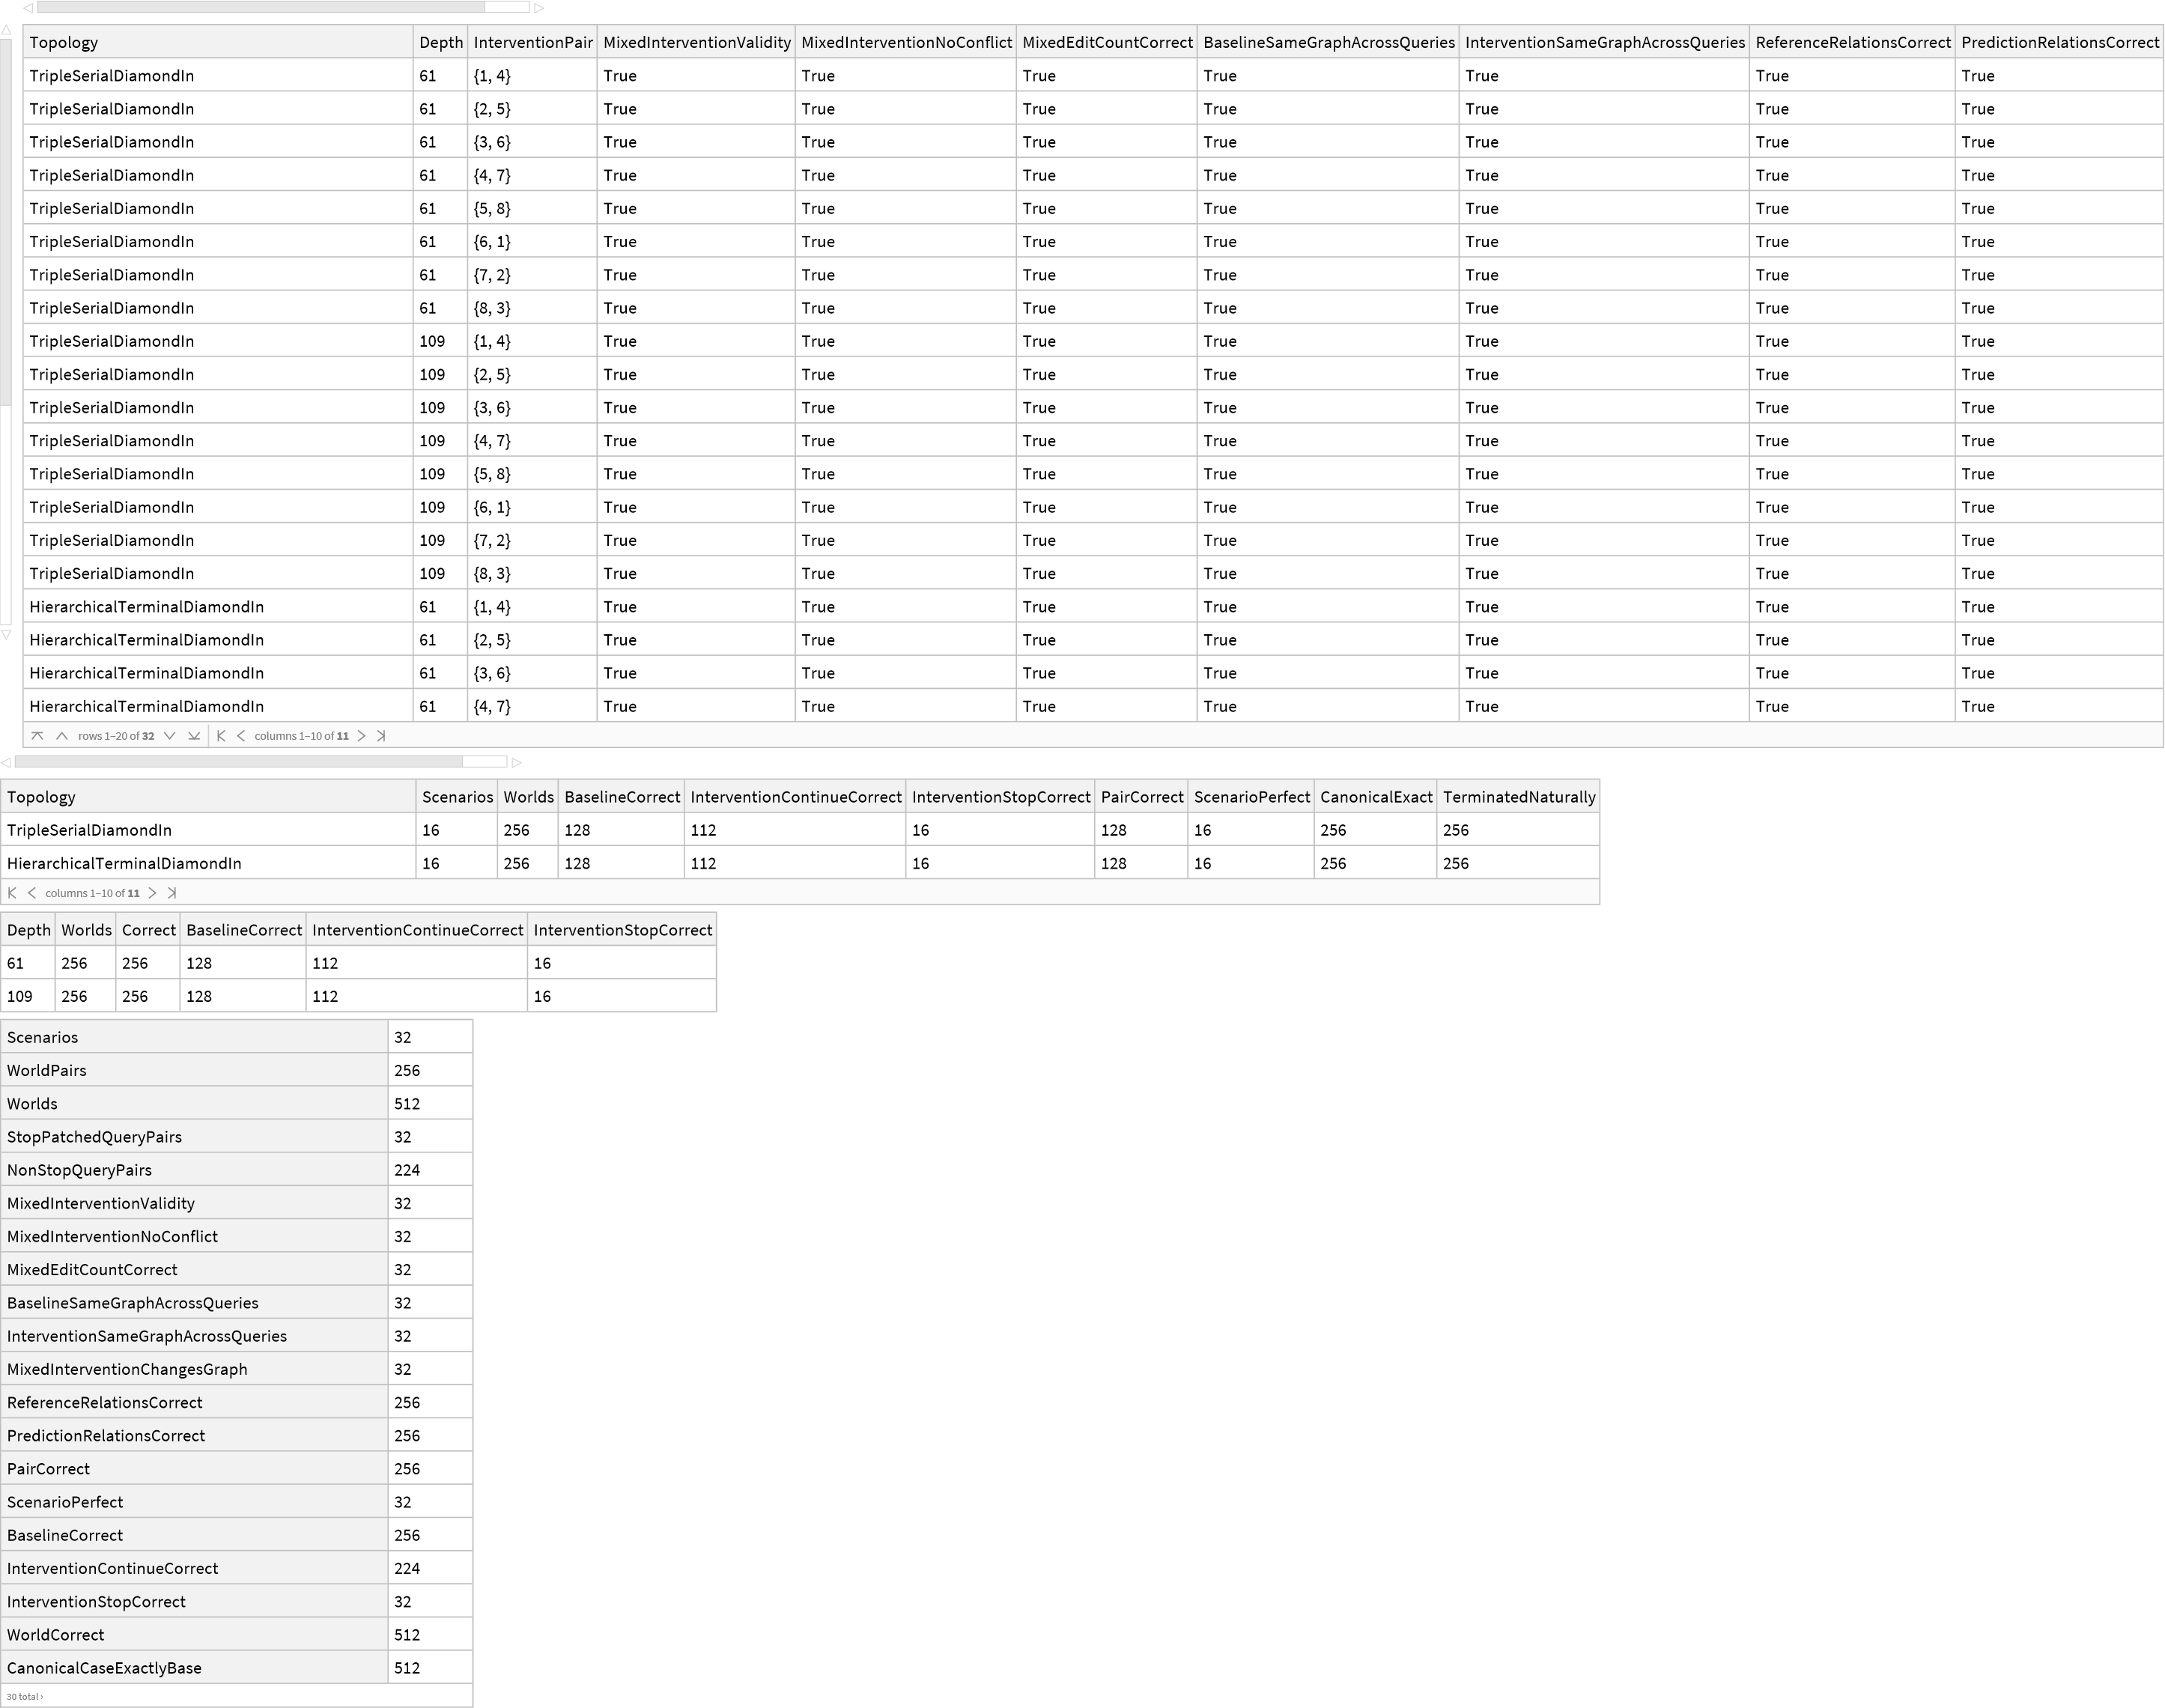

In [163]:
blindScenarios88=Flatten[
Table[
PrepareScenario88[topology,depth,interventionPair],
{topology,blindTopologies88},
{depth,blindDepths88},
{interventionPair,blindInterventionPairs88}
],
2
];

blindWorldPairs88=Flatten[Lookup[blindScenarios88,"WorldPairs"],1];
baselineWorlds88=Flatten[Lookup[blindScenarios88,"BaselineWorlds"],1];
interventionWorlds88=Flatten[
Lookup[blindScenarios88,"InterventionWorlds"],1
];
blindWorlds88=Join[baselineWorlds88,interventionWorlds88];

summary88=<|
"Scenarios"->Length[blindScenarios88],
"WorldPairs"->Length[blindWorldPairs88],
"Worlds"->Length[blindWorlds88],
"StopPatchedQueryPairs"->Count[
blindWorldPairs88,p_/;TrueQ[p["StopPatchedQuery"]]
],
"NonStopQueryPairs"->Count[
blindWorldPairs88,p_/;!TrueQ[p["StopPatchedQuery"]]
],
"MixedInterventionValidity"->Count[
blindScenarios88,s_/;TrueQ[s["MixedInterventionValidity"]]
],
"MixedInterventionNoConflict"->Count[
blindScenarios88,s_/;TrueQ[s["MixedInterventionNoConflict"]]
],
"MixedEditCountCorrect"->Count[
blindScenarios88,s_/;TrueQ[s["MixedEditCountCorrect"]]
],
"BaselineSameGraphAcrossQueries"->Count[
blindScenarios88,s_/;TrueQ[s["BaselineSameGraphAcrossQueries"]]
],
"InterventionSameGraphAcrossQueries"->Count[
blindScenarios88,s_/;TrueQ[s["InterventionSameGraphAcrossQueries"]]
],
"MixedInterventionChangesGraph"->Count[
blindScenarios88,s_/;TrueQ[s["MixedInterventionChangesGraph"]]
],
"ReferenceRelationsCorrect"->Count[
blindWorldPairs88,p_/;TrueQ[p["ReferenceRelationCorrect"]]
],
"PredictionRelationsCorrect"->Count[
blindWorldPairs88,p_/;TrueQ[p["PredictionRelationCorrect"]]
],
"PairCorrect"->Count[
blindWorldPairs88,p_/;TrueQ[p["PairCorrect"]]
],
"ScenarioPerfect"->Count[
blindScenarios88,s_/;TrueQ[s["AllSixteenWorldsCorrect"]]
],
"BaselineCorrect"->Count[baselineWorlds88,w_/;TrueQ[w["Correct"]]],
"InterventionContinueCorrect"->Count[
interventionWorlds88,
w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"InterventionStopCorrect"->Count[
interventionWorlds88,
w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"WorldCorrect"->Count[blindWorlds88,w_/;TrueQ[w["Correct"]]],
"CanonicalCaseExactlyBase"->Count[
blindWorlds88,w_/;TrueQ[w["CanonicalCaseExactlyBase"]]
],
"ContractionCountCorrect"->Count[
blindWorlds88,w_/;TrueQ[w["ContractionCountCorrect"]]
],
"ProtectedNodesPreserved"->Count[
blindWorlds88,w_/;TrueQ[w["ProtectedNodesPreserved"]]
],
"ReferenceActionsCorrect"->Count[
blindWorlds88,w_/;SameQ[w["ReferenceAction"],w["Target"]]
],
"NonEmptyTokens"->Count[blindWorlds88,w_/;w["TokenCount"]>0],
"TerminatedNaturally"->Count[
blindWorlds88,w_/;TrueQ[w["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[
blindWorlds88,w_/;TrueQ[w["HitSafetyCap"]]
],
"EightBranchWorlds"->Count[
blindWorlds88,w_/;SameQ[w["BranchCount"],8]
],
"ValidFeatureVectors"->Count[blindWorlds88,w_/;
VectorQ[w["FeatureVector"],IntegerQ]&&Length[w["FeatureVector"]]===27],
"PredictionFailures"->Count[blindWorlds88,w_/;SameQ[w["Prediction"],$Failed]],
"TotalTraceSeconds"->Total@Lookup[blindWorlds88,"TraceSeconds"]
|>;

byTopology88=Map[
Function[topology,
Module[{scenarios,pairs,base,intervention,worlds},
scenarios=Select[blindScenarios88,SameQ[#["Topology"],topology]&];
pairs=Flatten[Lookup[scenarios,"WorldPairs"],1];
base=Flatten[Lookup[scenarios,"BaselineWorlds"],1];
intervention=Flatten[Lookup[scenarios,"InterventionWorlds"],1];
worlds=Join[base,intervention];
<|
"Topology"->topology,
"Scenarios"->Length[scenarios],
"Worlds"->Length[worlds],
"BaselineCorrect"->Count[base,w_/;TrueQ[w["Correct"]]],
"InterventionContinueCorrect"->Count[
intervention,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"InterventionStopCorrect"->Count[
intervention,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
],
"PairCorrect"->Count[pairs,p_/;TrueQ[p["PairCorrect"]]],
"ScenarioPerfect"->Count[
scenarios,s_/;TrueQ[s["AllSixteenWorldsCorrect"]]
],
"CanonicalExact"->Count[
worlds,w_/;TrueQ[w["CanonicalCaseExactlyBase"]]
],
"TerminatedNaturally"->Count[
worlds,w_/;TrueQ[w["TerminatedNaturally"]]
],
"TraceSeconds"->Total@Lookup[worlds,"TraceSeconds"]
|>
]
],
blindTopologies88
];


byDepth88=Map[
Function[depth,
Module[{worlds,base,intervention},
worlds=Select[blindWorlds88,SameQ[#1["Depth"],depth]&];
base=Select[worlds,SameQ[#1["GraphCondition"],"Baseline"]&];
intervention=Select[
worlds,SameQ[#1["GraphCondition"],"MixedPathCutStopIntervention"]&
];
<|
"Depth"->depth,
"Worlds"->Length[worlds],
"Correct"->Count[worlds,w_/;TrueQ[w["Correct"]]],
"BaselineCorrect"->Count[base,w_/;TrueQ[w["Correct"]]],
"InterventionContinueCorrect"->Count[
intervention,w_/;SameQ[w["Target"],"Continue"]&&TrueQ[w["Correct"]]
],
"InterventionStopCorrect"->Count[
intervention,w_/;SameQ[w["Target"],"Stop"]&&TrueQ[w["Correct"]]
]
|>
]
],
blindDepths88
];

Column[{
Dataset[Map[
KeyTake[#,{"Topology","Depth","InterventionPair",
"MixedInterventionValidity","MixedInterventionNoConflict","MixedEditCountCorrect",
"BaselineSameGraphAcrossQueries","InterventionSameGraphAcrossQueries",
"ReferenceRelationsCorrect","PredictionRelationsCorrect",
"AllSixteenWorldsCorrect"}]&,
blindScenarios88
]],
Dataset[byTopology88],
Dataset[byDepth88],
Dataset[{summary88}]
}]


Dataset[{<|Stage -> S88, Name -> EightBranchFrozenDecoderBlind, 
 
>     CandidateHash -> 703e1365490a0123eac61745876dbcf29066abac4c753bb6ec1f61b790e222fe, 
 
>     CandidateFileHash -> 
 
>      82616c6acde25ecd7bbbc51bc80d03771ec8653bf033167ac9ccd74d7da01d91, 
 
>     ProtocolHash -> 4b4fb0b0c5c5dc91a4f37631b84658edaa81a8a7bd890e5527eebb040b4e19c7, 
 
>     TestDefinitionHash -> 
 
>      548ba783e7a60fdd378c51e34f627e7436038cc3b2cca855333ccde0be75c3ea, 
 
>     Depths -> {61, 109}, Topologies -> 
 
>      {TripleSerialDiamondIn, HierarchicalTerminalDiamondIn}, 
 
>     InterventionPairs -> 
 
>      {{1, 4}, {2, 5}, {3, 6}, {4, 7}, {5, 8}, {6, 1}, {7, 2}, {8, 3}}, 
 
>     Scenarios -> 32, WorldPairs -> 256, Worlds -> 512, BaselineCorrect -> 256, 
 
>     InterventionContinueCorrect -> 224, InterventionStopCorrect -> 32, 
 
>     WorldCorrect -> 512, Accuracy -> 1., BalancedAccuracy -> 1., PairCorrect -> 256, 
 
>     PredictionRelationsCorrect -> 256, ScenarioPerfect -> 32, 
 
>     OriginalFrozenModelChanged -> False, OriginalK33CandidateChanged -> False, 
 
>     FrozenDecoderChanged -> False, CoreChanged -> False, 
 
>     CanonicalizerChanged -> False, InterventionChanged -> False, 
 
>     TopologyPrimitivesChanged -> False, FeatureRuntimeChanged -> False, 
 
>     TestDefinitionChangedDuringRun -> False, ProtocolChangedDuringRun -> False, 
 
>     DeduplicationMechanismChanged -> False, ObservationAggregationChanged -> False, 
 
>     TestValidityPassed -> True, BlindPerfect -> True, 
 
>     CandidateFrozenBeforeS88 -> True, BlindProtocolHashedBeforeCases -> True, 
 
>     S87DDecoderUsed -> True, TrainingRun -> False, CandidateSearchRun -> False, 
 
>     DecoderEditApplied -> False, RetuningApplied -> False, 
 
>     HistoricalBlindTestsRerun -> False, S87LabelsReadByS88 -> False, 
 
>     AllEightQueryPositionsTestedPerGraph -> True, 
 
>     SameQueryBeforeAfterIntervention -> True, 
 
>     S88IsBlindCounterfactualCompositionTest -> True, 
 
>     MayClaimBlindEightBranchCompositionalTransfer -> True, 
 
>     MayClaimGeneralCounterfactualReasoning -> False, MayClaimCausalDiscovery -> False, 
 
>     TotalTraceSeconds -> 691.513, 
 
>     BlindResultHash -> 
 
>      186a089e97a3d0f3056a6f18a2420021bb7e6f7e4a478ad3c8ba06273a0b5fe8, 
 
>     Outcome -> S88_BLIND_EIGHT_BRANCH_FROZEN_DECODER_PASS, 
 
>     SuggestedNextStage -> S89_NEW_INTERVENTION_SEMANTICS_BLIND|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 54], 
 
>    1], <||>]
Dataset[{<|CertificateExported -> True, 
 
>     CertificatePath -> E:/engine_wolf/TCCT_S88_BlindResultCertificate.json, 
 
>     CertificateFileHash -> 
 
>      1c56bb0a87eba871f8474a93d4206d6aebbf1d66412a0d3927e62155a81e2fa4|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{CertificateExported, CertificatePath, 
 
>      CertificateFileHash}, {TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[String], TypeSystem`Atom[String]}], 1], <||>]
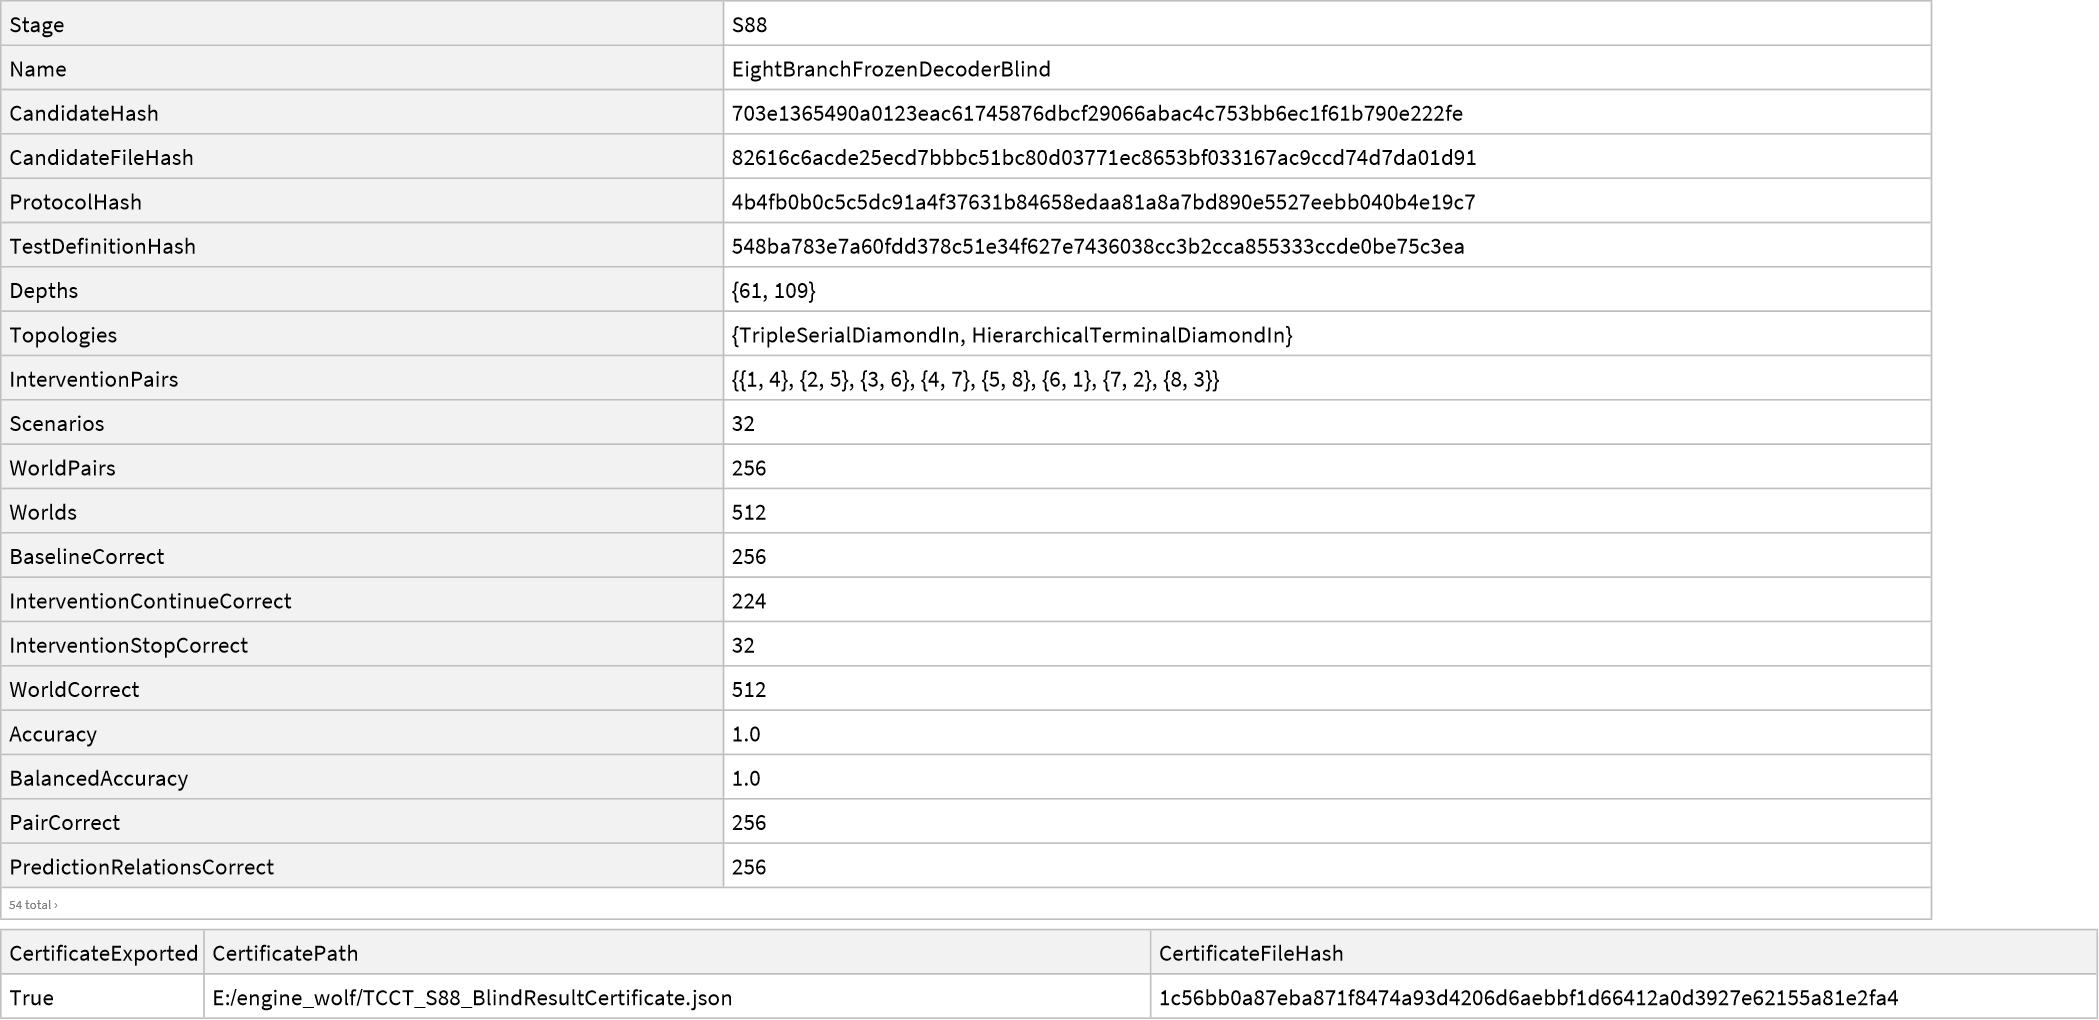

In [172]:
modelHashAfter88=Hash[Normal[frozen75D],"SHA256","HexString"];
k33ObjectHashAfter88=Hash[
Normal[frozenCandidate86E],"SHA256","HexString"
];
decoderObjectHashAfter88=Hash[
Normal[KeyDrop[frozenDecoderLoaded88,{"Classifier"}]],
"SHA256","HexString"
];
coreHashAfter88=Hash[CoreDefinitionBundle88[],"SHA256","HexString"];
canonicalizerHashAfter88=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256","HexString"
];
interventionHashAfter88=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256","HexString"
];
topologyPrimitiveHashAfter88=Hash[
{
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[HierarchicalDiamondIn80]
},
"SHA256","HexString"
];
decoderRuntimeDefinitionHashAfter88=Hash[
TCCTFrozenFeatureDefinitionBundleS87D[],"SHA256","HexString"
];
testDefinitionHashAfter88=Hash[
S88TestDefinitionBundle[],"SHA256","HexString"
];
protocolHashAfter88=Hash[Normal[protocol88],"SHA256","HexString"];

k33CandidateFileHashAfter88=FileSHA256Hex88[k33CandidatePath88];
decoderRuntimeFileHashAfter88=FileSHA256Hex88[decoderRuntimePath88];
decoderCandidateFileHashAfter88=FileSHA256Hex88[decoderCandidatePath88];
freezeCertificateFileHashAfter88=FileSHA256Hex88[freezeCertificatePath88];

originalFrozenModelUnchanged88=SameQ[
modelHashBefore88,modelHashAfter88,expectedFrozenModelHash88
];
k33CandidateUnchanged88=And[
SameQ[k33ObjectHashBefore88,k33ObjectHashAfter88],
SameQ[k33ObjectHashAfter88,expectedK33CandidateHash88],
SameQ[k33CandidateFileHashBefore88,k33CandidateFileHashAfter88],
SameQ[k33CandidateFileHashAfter88,expectedK33CandidateFileHash88]
];
frozenDecoderUnchanged88=And[
SameQ[decoderObjectHashBefore88,decoderObjectHashAfter88],
SameQ[decoderCandidateHashLoaded88,expectedDecoderCandidateHash88],
SameQ[decoderCandidateFileHashBefore88,decoderCandidateFileHashAfter88],
SameQ[decoderCandidateFileHashAfter88,expectedDecoderCandidateFileHash88]
];
coreUnchanged88=SameQ[coreHashBefore88,coreHashAfter88];
canonicalizerUnchanged88=SameQ[
canonicalizerHashBefore88,canonicalizerHashAfter88
];
interventionUnchanged88=SameQ[
interventionHashBefore88,interventionHashAfter88
];
topologyPrimitivesUnchanged88=SameQ[
topologyPrimitiveHashBefore88,topologyPrimitiveHashAfter88
];
decoderRuntimeUnchanged88=And[
SameQ[
decoderRuntimeDefinitionHashBefore88,
decoderRuntimeDefinitionHashAfter88
],
SameQ[decoderRuntimeFileHashBefore88,decoderRuntimeFileHashAfter88],
SameQ[decoderRuntimeFileHashAfter88,expectedFeatureRuntimeFileHash88]
];
testDefinitionUnchanged88=SameQ[
testDefinitionHashBefore88,testDefinitionHashAfter88
];
protocolUnchanged88=SameQ[protocolHash88,protocolHashAfter88];
freezeCertificateUnchanged88=And[
SameQ[
freezeCertificateFileHashBefore88,
freezeCertificateFileHashAfter88
],
SameQ[
freezeCertificateFileHashAfter88,
expectedFreezeCertificateFileHash88
]
];
observationAggregationUnchanged88=SameQ[
protocol88["ObservationAggregation"],
"FullQueriedObservationMultisetWithoutCodeDeduplication"
];

testValidityPassed88=And[
TrueQ[preflightPassed88],
TrueQ[originalFrozenModelUnchanged88],
TrueQ[k33CandidateUnchanged88],
TrueQ[frozenDecoderUnchanged88],
TrueQ[coreUnchanged88],
TrueQ[canonicalizerUnchanged88],
TrueQ[interventionUnchanged88],
TrueQ[topologyPrimitivesUnchanged88],
TrueQ[decoderRuntimeUnchanged88],
TrueQ[testDefinitionUnchanged88],
TrueQ[protocolUnchanged88],
TrueQ[freezeCertificateUnchanged88],
TrueQ[observationAggregationUnchanged88],
TrueQ[protocol88["NoCaseEvaluatedBeforeProtocolHash"]],
SameQ[summary88["Scenarios"],32],
SameQ[summary88["WorldPairs"],256],
SameQ[summary88["Worlds"],512],
SameQ[summary88["StopPatchedQueryPairs"],32],
SameQ[summary88["NonStopQueryPairs"],224],
SameQ[summary88["MixedInterventionValidity"],32],
SameQ[summary88["MixedInterventionNoConflict"],32],
SameQ[summary88["MixedEditCountCorrect"],32],
SameQ[summary88["BaselineSameGraphAcrossQueries"],32],
SameQ[summary88["InterventionSameGraphAcrossQueries"],32],
SameQ[summary88["MixedInterventionChangesGraph"],32],
SameQ[summary88["ReferenceRelationsCorrect"],256],
SameQ[summary88["CanonicalCaseExactlyBase"],512],
SameQ[summary88["ContractionCountCorrect"],512],
SameQ[summary88["ProtectedNodesPreserved"],512],
SameQ[summary88["ReferenceActionsCorrect"],512],
SameQ[summary88["NonEmptyTokens"],512],
SameQ[summary88["ValidFeatureVectors"],512],
SameQ[summary88["PredictionFailures"],0],
SameQ[summary88["TerminatedNaturally"],512],
SameQ[summary88["HitSafetyCap"],0],
SameQ[summary88["EightBranchWorlds"],512]
];

blindPerfect88=And[
TrueQ[testValidityPassed88],
SameQ[summary88["BaselineCorrect"],256],
SameQ[summary88["InterventionContinueCorrect"],224],
SameQ[summary88["InterventionStopCorrect"],32],
SameQ[summary88["WorldCorrect"],512],
SameQ[summary88["PairCorrect"],256],
SameQ[summary88["PredictionRelationsCorrect"],256],
SameQ[summary88["ScenarioPerfect"],32]
];

continueCases88=480;
stopCases88=32;
continueCorrect88=
summary88["BaselineCorrect"]+summary88["InterventionContinueCorrect"];
stopCorrect88=summary88["InterventionStopCorrect"];
accuracy88=N[summary88["WorldCorrect"]/512];
balancedAccuracy88=N@Mean[{
continueCorrect88/continueCases88,
stopCorrect88/stopCases88
}];

resultPayload88=<|
"Stage"->"S88",
"Name"->"EightBranchFrozenDecoderBlind",
"CandidateHash"->decoderCandidateHashLoaded88,
"CandidateFileHash"->decoderCandidateFileHashAfter88,
"ProtocolHash"->protocolHashAfter88,
"TestDefinitionHash"->testDefinitionHashAfter88,
"Depths"->blindDepths88,
"Topologies"->blindTopologies88,
"InterventionPairs"->blindInterventionPairs88,
"Scenarios"->summary88["Scenarios"],
"WorldPairs"->summary88["WorldPairs"],
"Worlds"->summary88["Worlds"],
"BaselineCorrect"->summary88["BaselineCorrect"],
"InterventionContinueCorrect"->
summary88["InterventionContinueCorrect"],
"InterventionStopCorrect"->summary88["InterventionStopCorrect"],
"WorldCorrect"->summary88["WorldCorrect"],
"Accuracy"->accuracy88,
"BalancedAccuracy"->balancedAccuracy88,
"PairCorrect"->summary88["PairCorrect"],
"PredictionRelationsCorrect"->summary88["PredictionRelationsCorrect"],
"ScenarioPerfect"->summary88["ScenarioPerfect"],
"OriginalFrozenModelChanged"->!TrueQ[originalFrozenModelUnchanged88],
"OriginalK33CandidateChanged"->!TrueQ[k33CandidateUnchanged88],
"FrozenDecoderChanged"->!TrueQ[frozenDecoderUnchanged88],
"CoreChanged"->!TrueQ[coreUnchanged88],
"CanonicalizerChanged"->!TrueQ[canonicalizerUnchanged88],
"InterventionChanged"->!TrueQ[interventionUnchanged88],
"TopologyPrimitivesChanged"->!TrueQ[topologyPrimitivesUnchanged88],
"FeatureRuntimeChanged"->!TrueQ[decoderRuntimeUnchanged88],
"TestDefinitionChangedDuringRun"->!TrueQ[testDefinitionUnchanged88],
"ProtocolChangedDuringRun"->!TrueQ[protocolUnchanged88],
"DeduplicationMechanismChanged"->!TrueQ[coreUnchanged88],
"ObservationAggregationChanged"->!TrueQ[observationAggregationUnchanged88],
"TestValidityPassed"->testValidityPassed88,
"BlindPerfect"->blindPerfect88
|>;

blindResultHash88=Hash[
Normal[resultPayload88],"SHA256","HexString"
];

cert88=Join[
resultPayload88,
<|
"CandidateFrozenBeforeS88"->True,
"BlindProtocolHashedBeforeCases"->True,
"S87DDecoderUsed"->True,
"TrainingRun"->False,
"CandidateSearchRun"->False,
"DecoderEditApplied"->False,
"RetuningApplied"->False,
"HistoricalBlindTestsRerun"->False,
"S87LabelsReadByS88"->False,
"AllEightQueryPositionsTestedPerGraph"->True,
"SameQueryBeforeAfterIntervention"->True,
"S88IsBlindCounterfactualCompositionTest"->True,
"MayClaimBlindEightBranchCompositionalTransfer"->blindPerfect88,
"MayClaimGeneralCounterfactualReasoning"->False,
"MayClaimCausalDiscovery"->False,
"TotalTraceSeconds"->summary88["TotalTraceSeconds"],
"BlindResultHash"->blindResultHash88,
"Outcome"->Which[
!TrueQ[testValidityPassed88],
"INVALID_S88_BLIND_TEST",
TrueQ[blindPerfect88],
"S88_BLIND_EIGHT_BRANCH_FROZEN_DECODER_PASS",
True,
"S88_VALID_BLIND_FAILURE_DO_NOT_RETUNE"
],
"SuggestedNextStage"->Which[
!TrueQ[testValidityPassed88],
"S88R_REPAIR_HARNESS_WITHOUT_MODEL_CHANGE",
TrueQ[blindPerfect88],
"S89_NEW_INTERVENTION_SEMANTICS_BLIND",
True,
"S88A_FAILURE_AUDIT_WITHOUT_RETUNING"
]
|>
];

certificateExportResult88=Quiet@Check[
Export[s88ResultCertificatePath,cert88,"RawJSON"],
$Failed
];
certificateExported88=And[
StringQ[certificateExportResult88],
FileExistsQ[s88ResultCertificatePath]
];

Column[{
Dataset[{cert88}],
Dataset[{<|
"CertificateExported"->certificateExported88,
"CertificatePath"->s88ResultCertificatePath,
"CertificateFileHash"->If[
certificateExported88,FileSHA256Hex88[s88ResultCertificatePath],Missing[]
]
|>}]
}]
